DATA INFO
Shape Train: (54808, 13)
Shape Test : (23490, 12)
Columns Train: ['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score', 'is_promoted']
Target Distribution:
is_promoted
0    50140
1     4668
Name: count, dtype: int64

PREPROCESSING
Missing values处理后: 0
Columns after preprocessing: ['department', 'education', 'gender', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score', 'is_promoted', 'total_score']

X_train shape: (43846, 10), y_train: {0: 40112, 1: 3734}
X_val shape: (10962, 10), y_val: {0: 10028, 1: 934}

APPLYING SMOTE
After SMOTE - X_train: (80224, 10), y_train: {0: 40112, 1: 40112}

TRAINING MULTIPLE MODELS

Logistic Regression:
  Accuracy : 0.6627
  Precision: 0.1494
  Recall   : 0.6306
  F1-Score : 0.2416

Decision Tree:
  Accuracy : 0.8643
  Precision: 0.2901
  Recall   : 0.409

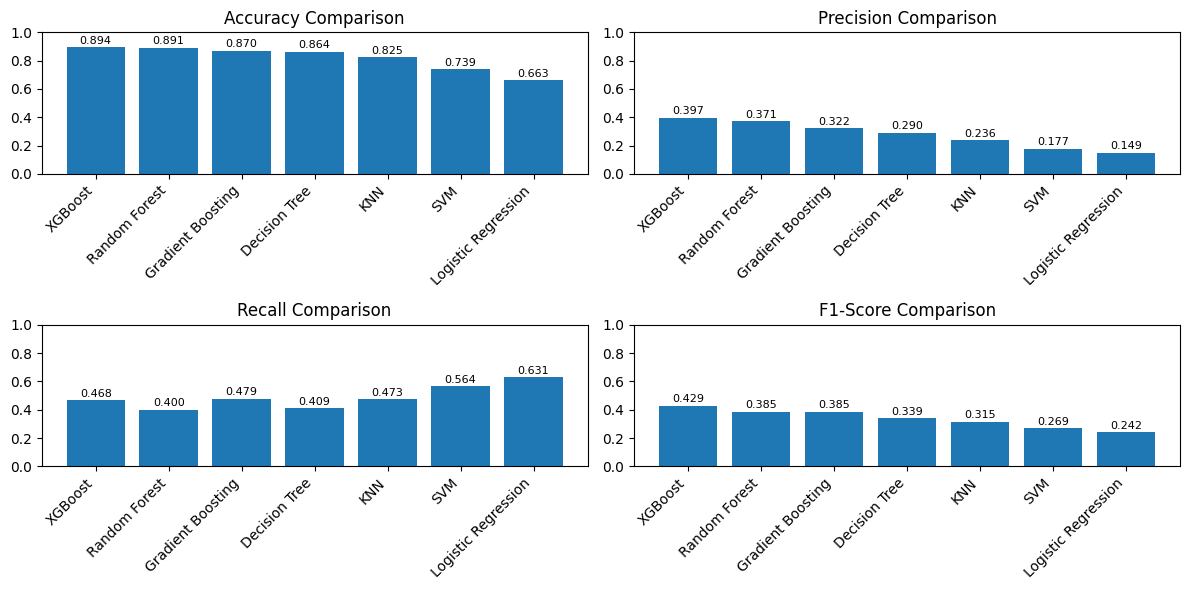


Best Model: XGBoost

Predictions saved to 'submission.csv'

FEATURE IMPORTANCE
             Feature  Importance
previous_year_rating    0.481250
          department    0.119111
  avg_training_score    0.090314
           education    0.073911
     no_of_trainings    0.064883
              gender    0.054694
                 age    0.033451
         awards_won?    0.032922
         total_score    0.025087
   length_of_service    0.024377


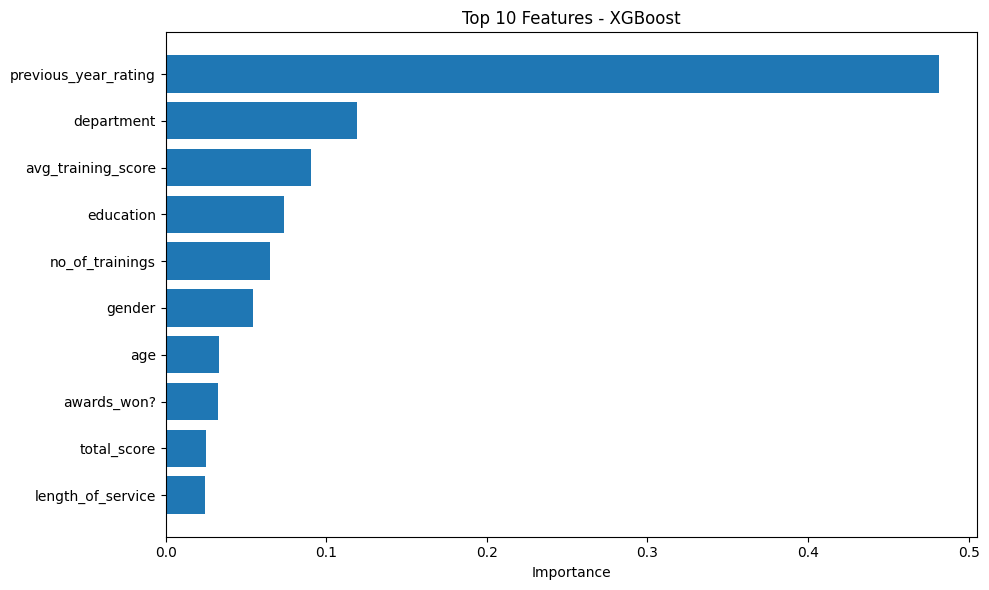

In [1]:
# ============================================
# PREDIKSI PROMOSI KARYAWAN - MULTIPLE MODELS
# ============================================

# 1. IMPORT LIBRARY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Resampling & Metrics
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# ============================================
# 2. LOAD DATASET (GANTI DENGAN PATH FILE ANDA)
# ============================================

# GANTI 'nama_file_train.csv' dan 'nama_file_test.csv' dengan nama file Anda
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("="*50)
print("DATA INFO")
print("="*50)
print(f"Shape Train: {train.shape}")
print(f"Shape Test : {test.shape}")
print(f"Columns Train: {train.columns.tolist()}")
print(f"Target Distribution:\n{train['is_promoted'].value_counts()}")

# ============================================
# 3. PREPROCESSING
# ============================================

print("\n" + "="*50)
print("PREPROCESSING")
print("="*50)

# 3.1 Handle Missing Values
train['education'] = train['education'].fillna(train['education'].mode()[0])
train['previous_year_rating'] = train['previous_year_rating'].fillna(train['previous_year_rating'].mode()[0])

test['education'] = test['education'].fillna(test['education'].mode()[0])
test['previous_year_rating'] = test['previous_year_rating'].fillna(test['previous_year_rating'].mode()[0])

print("Missing values处理后:", train.isnull().sum().sum())

# 3.2 Feature Engineering
# Konversi KPIs_met >80% ke numerik jika belum
if 'KPIs_met >80%' in train.columns:
    train['KPIs_met >80%'] = train['KPIs_met >80%'].astype(int)
    test['KPIs_met >80%'] = test['KPIs_met >80%'].astype(int)

train['total_score'] = train['avg_training_score'] * train['no_of_trainings']
test['total_score'] = test['avg_training_score'] * test['no_of_trainings']

# 3.3 Drop Unnecessary Columns
cols_to_drop = ['employee_id', 'recruitment_channel', 'region']
train = train.drop([c for c in cols_to_drop if c in train.columns], axis=1)
test = test.drop([c for c in cols_to_drop if c in test.columns], axis=1)

# 3.4 Encoding Categorical Columns
categorical_cols = ['department', 'education', 'gender']
for col in categorical_cols:
    if col in train.columns:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col])
        test[col] = le.transform(test[col])

print("Columns after preprocessing:", train.columns.tolist())

# ============================================
# 4. SPLIT DATA
# ============================================

X = train.drop('is_promoted', axis=1)
y = train['is_promoted']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}, y_train: {y_train.value_counts().to_dict()}")
print(f"X_val shape: {X_val.shape}, y_val: {y_val.value_counts().to_dict()}")

# ============================================
# 5. RESAMPLING with SMOTE
# ============================================

print("\n" + "="*50)
print("APPLYING SMOTE")
print("="*50)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - X_train: {X_train_resampled.shape}, y_train: {pd.Series(y_train_resampled).value_counts().to_dict()}")

# ============================================
# 6. FEATURE SCALING
# ============================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test)

# ============================================
# 7. MULTIPLE MODELS TRAINING & COMPARISON
# ============================================

print("\n" + "="*50)
print("TRAINING MULTIPLE MODELS")
print("="*50)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(random_state=42, probability=True)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train_resampled)
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_prob) if y_prob is not None else 0
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy : {accuracy_score(y_val, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_val, y_pred):.4f}")
    print(f"  F1-Score : {f1_score(y_val, y_pred):.4f}")

# ============================================
# 8. RESULTS COMPARISON TABLE
# ============================================

print("\n" + "="*50)
print("MODELS COMPARISON SUMMARY")
print("="*50)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)
print(results_df.to_string(index=False))

# ============================================
# 9. VISUALIZATION
# ============================================

# Plot Comparison
plt.figure(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    bars = plt.bar(results_df['Model'], results_df[metric])
    plt.title(f'{metric} Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# ============================================
# 10. BEST MODEL SELECTION & TRAINING
# ============================================

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")

# Train best model on FULL training data
best_model.fit(X_train_scaled, y_train_resampled)

# Predict on test set
test_predictions = best_model.predict(X_test_scaled)

# ============================================
# 11. SAVE PREDICTIONS
# ============================================

submission = pd.DataFrame({
    'employee_id': test['employee_id'] if 'employee_id' in test.columns else range(len(test_predictions)),
    'is_promoted': test_predictions
})
submission.to_csv('submission.csv', index=False)
print("\nPredictions saved to 'submission.csv'")

# ============================================
# 12. FEATURE IMPORTANCE (For Tree-based Models)
# ============================================

if hasattr(best_model, 'feature_importances_'):
    print("\n" + "="*50)
    print("FEATURE IMPORTANCE")
    print("="*50)
    feature_names = X.columns.tolist()
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)
    print(fi_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(fi_df['Feature'][:10], fi_df['Importance'][:10])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

DATA INGESTION - HR ANALYTICS DATASET
Shape Train: (54808, 13)
Shape Test : (23490, 12)

Target Distribution (is_promoted - CLASSIFICATION TARGET):
is_promoted
0    50140
1     4668
Name: count, dtype: int64

Persentase Promosi (Class 1): 8.52%
⚠️ Data tidak seimbang (Imbalanced) - Perlu SMOTE

PREPROCESSING - HANDLING MISSING VALUES & FEATURE ENGINEERING
Missing values setelah imputasi: 0
Columns setelah preprocessing: ['department', 'education', 'gender', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score', 'is_promoted', 'total_score', 'performance_index']

DATA BALANCING - SMOTE (Synthetic Minority Over-sampling)
BEFORE SMOTE - Class 0: 40112, Class 1: 3734
Imbalance Ratio: 0.0931

AFTER SMOTE  - Class 0: 40112, Class 1: 40112
Imbalance Ratio: 1.0000

CLASSIFICATION MODELING - PREDIKSI KELAYAKAN PROMOSI

TRAINING: MLP (Neural Network)
  ✅ Accuracy  : 0.8764
  ✅ Precision : 0.3372
  ✅ Recall    : 0.4668
  ✅ F1-Score  : 0.3916
  

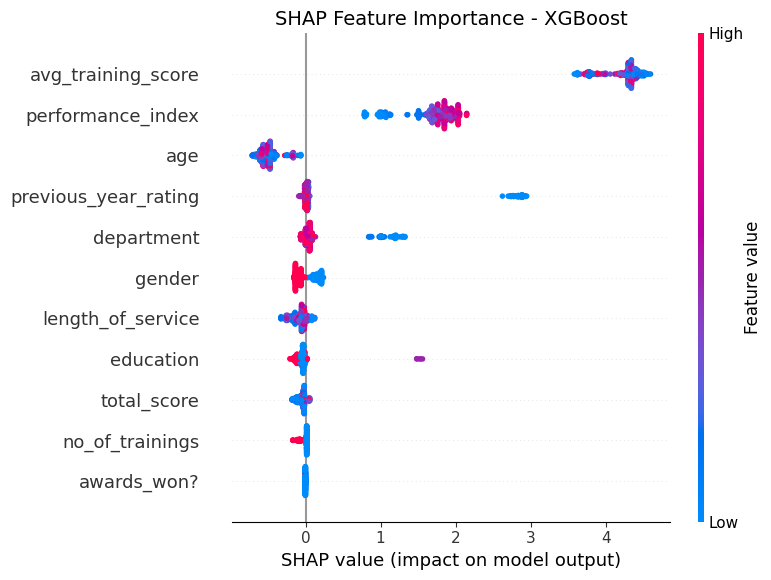

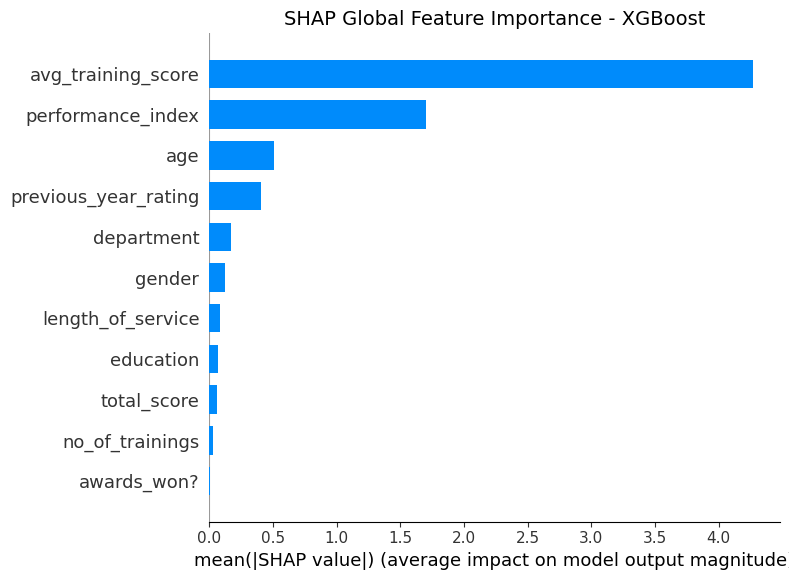

✅ SHAP analysis completed - visualisasi disimpan
⚠️ SHAP analysis error: only integer scalar arrays can be converted to a scalar index

WHAT-IF ANALYSIS - SIMULASI SKENARIO

📊 Skenario: Karyawan Senior dengan Masa Kerja 11 tahun
   Original ML Probability (Klasifikasi): 0.0603

📈 Simulasi Peningkatan Skor Pelatihan:
 Boost  New_Training_Score  ML_Probability  SAW_Score
     0                  57        0.060287   0.245415
    10                  67        0.205339   0.281894
    20                  77        0.571793   0.318372
    30                  87        0.740035   0.354851
    40                  97        0.996768   0.391329
    50                 100        0.996768   0.402273


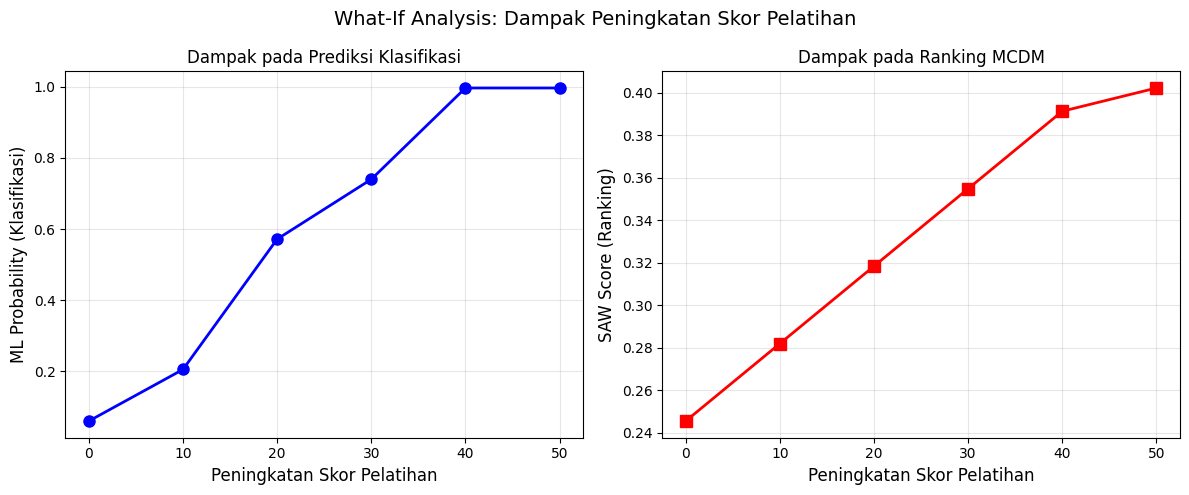


✅ What-If Analysis plot disimpan sebagai 'what_if_analysis.png'

SAVING RESULTS
✅ Submission file saved as 'submission.csv' (Hasil Klasifikasi)
✅ MCDM Ranking saved as 'mcdm_ranking.csv'

MODEL COMPARISON VISUALIZATION


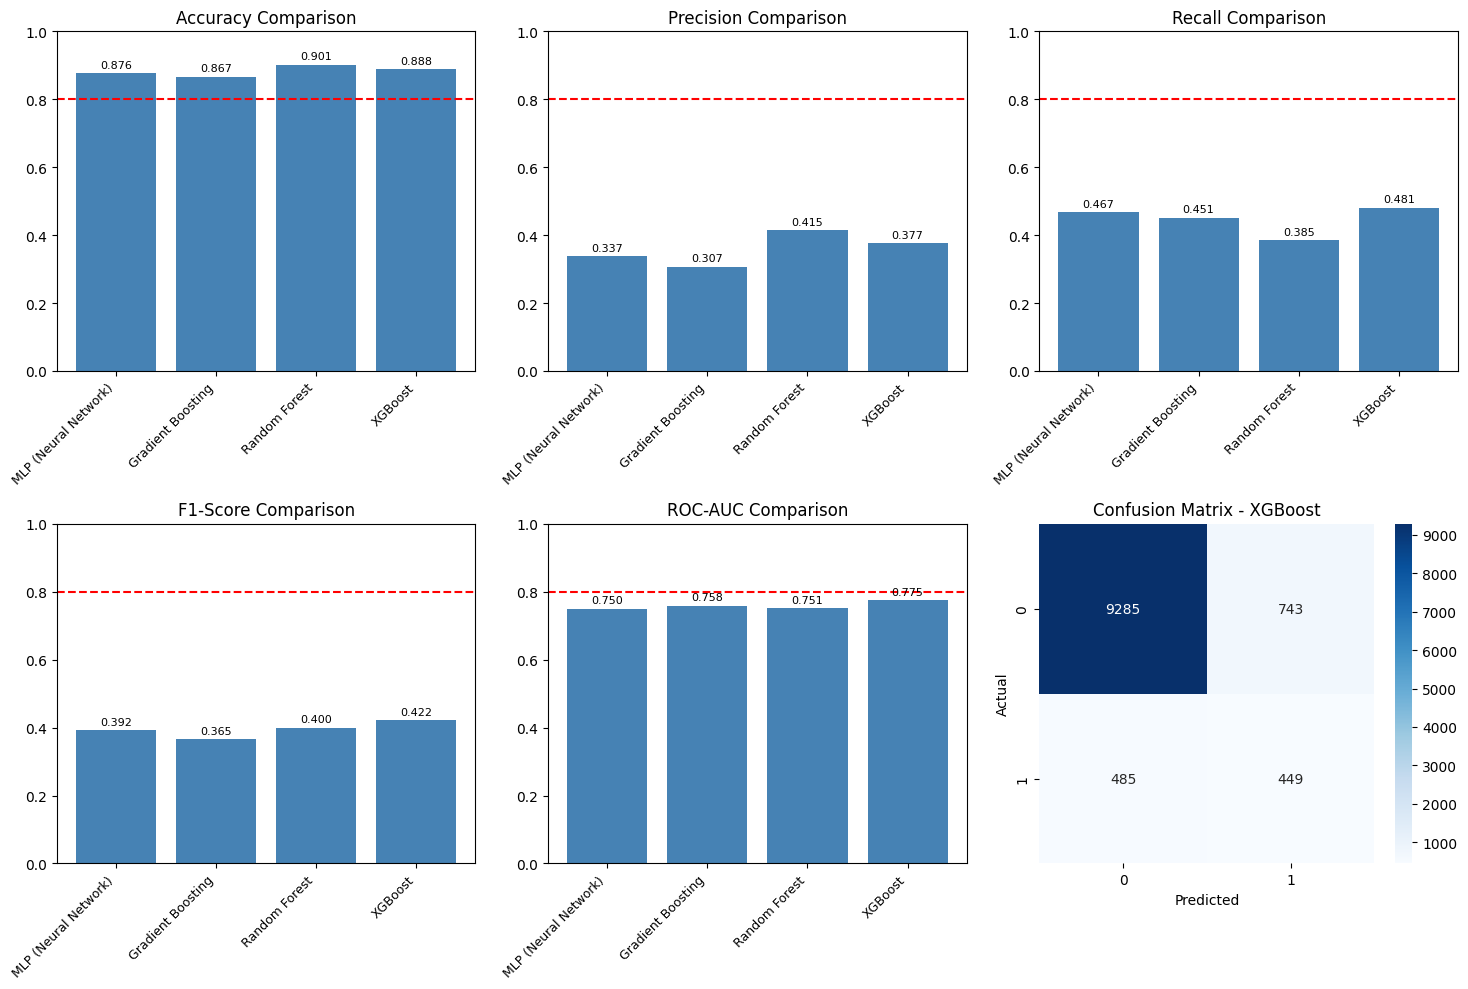

✅ Model comparison plot saved as 'model_comparison.png'

FINAL SUMMARY - SISTEM PENDUKUNG KEPUTUSAN PROMOSI

┌─────────────────────────────────────────────────────────────────────────────┐
│  HASIL SIMULASI HYBRID CLASSIFICATION + MCDM                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 KLASIFIKASI (Prediksi Kelayakan Promosi)                               │
│  ├─ Best Model              : XGBoost                            │
│  ├─ F1-Score                : 0.4224                                │
│  ├─ ROC-AUC                 : 0.7749                               │
│  └─ Data Balancing          : SMOTE                                        │
│                                                                             │
│  ⚖️ AHP WEIGHTING (Prioritas Kriteria)                                     │
│  ├─ Potensi Promosi (ML)    : 0.3793      

In [4]:
# ============================================
# SISTEM PENDUKUNG KEPUTUSAN PROMOSI KARYAWAN
# HYBRID CLASSIFICATION (ML) + MCDM (SAW/TOPSIS)
# ============================================

# 1. IMPORT LIBRARY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning - Classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Resampling & Metrics - CLASSIFICATION METRICS
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# SHAP untuk Explainability
import shap

# ============================================
# 2. LOAD DATASET (GANTI DENGAN PATH FILE ANDA)
# ============================================

# GANTI 'nama_file_train.csv' dan 'nama_file_test.csv' dengan nama file Anda
# Contoh: train = pd.read_csv('train.csv')
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("="*70)
print("DATA INGESTION - HR ANALYTICS DATASET")
print("="*70)
print(f"Shape Train: {train.shape}")
print(f"Shape Test : {test.shape}")
print(f"\nTarget Distribution (is_promoted - CLASSIFICATION TARGET):")
print(train['is_promoted'].value_counts())
print(f"\nPersentase Promosi (Class 1): {train['is_promoted'].mean()*100:.2f}%")
print(f"⚠️ Data tidak seimbang (Imbalanced) - Perlu SMOTE")

# ============================================
# 3. PREPROCESSING (Data Architect & Predictive Engineer)
# ============================================

print("\n" + "="*70)
print("PREPROCESSING - HANDLING MISSING VALUES & FEATURE ENGINEERING")
print("="*70)

# 3.1 Handle Missing Values
train['education'] = train['education'].fillna(train['education'].mode()[0])
train['previous_year_rating'] = train['previous_year_rating'].fillna(train['previous_year_rating'].mode()[0])

test['education'] = test['education'].fillna(test['education'].mode()[0])
test['previous_year_rating'] = test['previous_year_rating'].fillna(test['previous_year_rating'].mode()[0])

print(f"Missing values setelah imputasi: {train.isnull().sum().sum()}")

# 3.2 Feature Engineering untuk Klasifikasi
if 'KPIs_met >80%' in train.columns:
    train['KPIs_met >80%'] = train['KPIs_met >80%'].astype(int)
    test['KPIs_met >80%'] = test['KPIs_met >80%'].astype(int)

# Fitur agregat untuk meningkatkan performa klasifikasi
train['total_score'] = train['avg_training_score'] * train['no_of_trainings']
test['total_score'] = test['avg_training_score'] * test['no_of_trainings']
train['performance_index'] = train['previous_year_rating'] * train['avg_training_score'] / 100
test['performance_index'] = test['previous_year_rating'] * test['avg_training_score'] / 100

# 3.3 Drop Unnecessary Columns
cols_to_drop = ['employee_id', 'recruitment_channel', 'region']
train = train.drop([c for c in cols_to_drop if c in train.columns], axis=1)
test = test.drop([c for c in cols_to_drop if c in test.columns], axis=1)

# 3.4 Encoding Categorical Columns untuk Klasifikasi
categorical_cols = ['department', 'education', 'gender']
for col in categorical_cols:
    if col in train.columns:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col])
        test[col] = le.transform(test[col])

print(f"Columns setelah preprocessing: {train.columns.tolist()}")

# ============================================
# 4. DATA BALANCING with SMOTE (Untuk Klasifikasi)
# ============================================

print("\n" + "="*70)
print("DATA BALANCING - SMOTE (Synthetic Minority Over-sampling)")
print("="*70)

X = train.drop('is_promoted', axis=1)
y = train['is_promoted']  # TARGET CLASSIFICATION

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"BEFORE SMOTE - Class 0: {(y_train == 0).sum()}, Class 1: {(y_train == 1).sum()}")
print(f"Imbalance Ratio: {(y_train == 1).sum() / (y_train == 0).sum():.4f}")

# SMOTE untuk menyeimbangkan kelas
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nAFTER SMOTE  - Class 0: {(y_train_resampled == 0).sum()}, Class 1: {(y_train_resampled == 1).sum()}")
print(f"Imbalance Ratio: {(y_train_resampled == 1).sum() / (y_train_resampled == 0).sum():.4f}")

# ============================================
# 5. FEATURE SCALING
# ============================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test)

# ============================================
# 6. CLASSIFICATION MODELING (MLP & Gradient Boosting)
# ============================================

print("\n" + "="*70)
print("CLASSIFICATION MODELING - PREDIKSI KELAYAKAN PROMOSI")
print("="*70)

# Model Klasifikasi sesuai permintaan tugas
classification_models = {
    'MLP (Neural Network)': MLPClassifier(
        hidden_layer_sizes=(100, 50), 
        activation='relu',
        random_state=42, 
        max_iter=500, 
        early_stopping=True,
        verbose=False
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        random_state=42, 
        eval_metric='logloss',
        use_label_encoder=False
    )
}

results = []
best_model = None
best_f1 = 0
best_auc = 0

for name, model in classification_models.items():
    print(f"\n{'='*50}")
    print(f"TRAINING: {name}")
    print(f"{'='*50}")
    
    # Training
    model.fit(X_train_scaled, y_train_resampled)
    
    # Prediction
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled)[:, 1]
    
    # CLASSIFICATION METRICS
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })
    
    print(f"  ✅ Accuracy  : {acc:.4f}")
    print(f"  ✅ Precision : {prec:.4f}")
    print(f"  ✅ Recall    : {rec:.4f}")
    print(f"  ✅ F1-Score  : {f1:.4f}")
    print(f"  ✅ ROC-AUC   : {auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    print(f"\n  Confusion Matrix:")
    print(f"    TN: {cm[0,0]:5d} | FP: {cm[0,1]:5d}")
    print(f"    FN: {cm[1,0]:5d} | TP: {cm[1,1]:5d}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_auc = auc
        best_model = model
        best_model_name = name

# ============================================
# FIX: Perbaikan pengambilan data dari results
# ============================================
print(f"\n{'='*70}")
print(f"🏆 BEST CLASSIFICATION MODEL: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f} | ROC-AUC: {best_auc:.4f}")
print(f"{'='*70}")

# ============================================
# 7. CLASSIFICATION REPORT (Detailed)
# ============================================

print("\n" + "="*70)
print("CLASSIFICATION REPORT - BEST MODEL")
print("="*70)

best_model.fit(X_train_scaled, y_train_resampled)
y_pred_best = best_model.predict(X_val_scaled)
print(classification_report(y_val, y_pred_best, target_names=['Tidak Promosi', 'Promosi']))

# ============================================
# 8. DECISION MATRIX DESIGN (Integrasi ML + MCDM)
# ============================================

print("\n" + "="*70)
print("DECISION MATRIX DESIGN - INTEGRASI ML PROBABILITY + KRITERIA MCDM")
print("="*70)

# Predict probabilities untuk SEMUA data training
X_all_scaled = scaler.transform(X)
ml_probabilities = best_model.predict_proba(X_all_scaled)[:, 1]

# Create Decision Matrix untuk MCDM
decision_matrix = X.copy()
decision_matrix['ML_Probability'] = ml_probabilities  # Output dari CLASSIFICATION
decision_matrix['actual_promoted'] = y

# Kriteria untuk MCDM (semua benefit/maximize)
criteria = ['ML_Probability', 'length_of_service', 'awards_won?', 'avg_training_score', 'previous_year_rating']
criteria_names = {
    'ML_Probability': 'Potensi Promosi (Hasil Klasifikasi ML)',
    'length_of_service': 'Masa Kerja (Loyalitas)',
    'awards_won?': 'Penghargaan',
    'avg_training_score': 'Skor Pelatihan',
    'previous_year_rating': 'Rating Kinerja'
}

print("\nKriteria MCDM (5 kriteria):")
for i, c in enumerate(criteria, 1):
    print(f"  {i}. {criteria_names[c]}")

# ============================================
# 9. AHP WEIGHTING (Pairwise Comparison Matrix)
# ============================================

print("\n" + "="*70)
print("AHP WEIGHTING - PENENTUAN PRIORITAS KRITERIA")
print("="*70)

# Matriks Pairwise Comparison (Saaty Scale 1-9)
# Prioritas organisasi: lebih mengutamakan kinerja (ML & Rating) daripada senioritas
pairwise = np.array([
    [1,   5,   3,   2,   2],   # ML_Probability vs lainnya
    [1/5, 1,   1/3, 1/4, 1/4], # length_of_service vs lainnya
    [1/3, 3,   1,   1/2, 1/2], # awards_won? vs lainnya
    [1/2, 4,   2,   1,   1],   # avg_training_score vs lainnya
    [1/2, 4,   2,   1,   1]    # previous_year_rating vs lainnya
])

# Hitung bobot AHP
eigenvals, eigenvecs = np.linalg.eig(pairwise)
principal_eigenvec = eigenvecs[:, np.argmax(eigenvals)].real
weights = principal_eigenvec / principal_eigenvec.sum()

# Consistency Ratio
n = len(pairwise)
lambda_max = np.max(eigenvals).real
CI = (lambda_max - n) / (n - 1)
RI = {1:0, 2:0, 3:0.58, 4:0.9, 5:1.12, 6:1.24, 7:1.32, 8:1.41, 9:1.45}[n]
CR = CI / RI

print("\nAHP Weights (Prioritas Kriteria):")
for i, c in enumerate(criteria):
    print(f"  {criteria_names[c]}: {weights[i]:.4f}")
print(f"\nConsistency Ratio (CR): {CR:.4f}")
print(f"Status: {'✓ KONSISTEN (CR < 0.1)' if CR < 0.1 else '✗ TIDAK KONSISTEN'}")

# ============================================
# 10. MCDM IMPLEMENTATION (SAW & TOPSIS)
# ============================================

print("\n" + "="*70)
print("MCDM IMPLEMENTATION - SAW & TOPSIS")
print("="*70)

# Normalization (Min-Max untuk benefit criteria)
normalized = pd.DataFrame()
for i, criterion in enumerate(criteria):
    min_val = decision_matrix[criterion].min()
    max_val = decision_matrix[criterion].max()
    if max_val - min_val > 0:
        normalized[criterion] = (decision_matrix[criterion] - min_val) / (max_val - min_val)
    else:
        normalized[criterion] = 1

# SAW (Simple Additive Weighting)
saw_scores = np.zeros(len(decision_matrix))
for i, criterion in enumerate(criteria):
    saw_scores += normalized[criterion].values * weights[i]
decision_matrix['SAW_Score'] = saw_scores

# TOPSIS
weighted_normalized = normalized * weights
ideal_best = weighted_normalized.max()
ideal_worst = weighted_normalized.min()
dist_to_best = np.sqrt(((weighted_normalized - ideal_best) ** 2).sum(axis=1))
dist_to_worst = np.sqrt(((weighted_normalized - ideal_worst) ** 2).sum(axis=1))
topsis_scores = dist_to_worst / (dist_to_best + dist_to_worst)
decision_matrix['TOPSIS_Score'] = topsis_scores

# Ranking
decision_matrix['SAW_Rank'] = decision_matrix['SAW_Score'].rank(ascending=False)
decision_matrix['TOPSIS_Rank'] = decision_matrix['TOPSIS_Score'].rank(ascending=False)

print(f"✅ SAW dan TOPSIS berhasil dihitung untuk {len(decision_matrix)} karyawan")

# ============================================
# 11. RANKING KANDIDAT PROMOSI (Top 10)
# ============================================

print("\n" + "="*70)
print("RANKING 10 KANDIDAT TERBAIK (SAW)")
print("="*70)

top_10 = decision_matrix.nsmallest(10, 'SAW_Rank')
for idx, row in top_10.iterrows():
    print(f"Rank {int(row['SAW_Rank']):2d} | SAW: {row['SAW_Score']:.4f} | "
          f"ML Prob: {row['ML_Probability']:.4f} | Masa Kerja: {row['length_of_service']} | "
          f"Awards: {int(row['awards_won?'])}")

# ============================================
# 12. SHAP ANALYSIS (Transparency & Bias Audit)
# ============================================

print("\n" + "="*70)
print("SHAP ANALYSIS - MODEL TRANSPARANCY & BIAS AUDIT")
print("="*70)

# Gunakan subset untuk SHAP
X_sample = X_train_resampled[:500]
if hasattr(best_model, 'get_booster') or hasattr(best_model, 'feature_importances_'):
    try:
        # Untuk XGBoost, Random Forest, Gradient Boosting
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_sample)
        
        # SHAP Summary Plot
        plt.figure(figsize=(12, 6))
        shap.summary_plot(shap_values, X_sample, feature_names=X.columns.tolist(), show=False)
        plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14)
        plt.tight_layout()
        plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # SHAP Bar Plot
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_sample, feature_names=X.columns.tolist(), plot_type="bar", show=False)
        plt.title(f'SHAP Global Feature Importance - {best_model_name}', fontsize=14)
        plt.tight_layout()
        plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("✅ SHAP analysis completed - visualisasi disimpan")
        
        # Insight dari SHAP
        shap_importance = np.abs(shap_values).mean(axis=0)
        top_features = X.columns.tolist()[np.argsort(shap_importance)[-5:][::-1]]
        print(f"\n🔍 Top 5 Fitur Paling Berpengaruh menurut SHAP:")
        for i, f in enumerate(top_features, 1):
            print(f"   {i}. {f}")
    except Exception as e:
        print(f"⚠️ SHAP analysis error: {e}")
else:
    print("⚠️ SHAP analysis untuk tree-based models (Random Forest, XGBoost, Gradient Boosting)")

# ============================================
# 13. WHAT-IF ANALYSIS (Policy Simulation)
# ============================================

print("\n" + "="*70)
print("WHAT-IF ANALYSIS - SIMULASI SKENARIO")
print("="*70)

# Pilih karyawan dengan masa kerja lama vs performa rendah
low_perf_senior = X[(X['length_of_service'] > 10) & (X['avg_training_score'] < 60)]
if len(low_perf_senior) > 0:
    test_employee = low_perf_senior.iloc[0:1].copy()
    original_prob = best_model.predict_proba(scaler.transform(test_employee))[0, 1]
    
    print(f"\n📊 Skenario: Karyawan Senior dengan Masa Kerja {test_employee['length_of_service'].values[0]} tahun")
    print(f"   Original ML Probability (Klasifikasi): {original_prob:.4f}")
    
    # Simulasi peningkatan skor pelatihan
    scenarios = []
    for boost in [0, 10, 20, 30, 40, 50]:
        test_scenario = test_employee.copy()
        test_scenario['avg_training_score'] = min(100, test_scenario['avg_training_score'].values[0] + boost)
        test_scenario['total_score'] = test_scenario['avg_training_score'] * test_scenario['no_of_trainings']
        test_scenario['performance_index'] = test_scenario['previous_year_rating'] * test_scenario['avg_training_score'] / 100
        
        ml_prob = best_model.predict_proba(scaler.transform(test_scenario))[0, 1]
        
        # Re-calculate MCDM SAW score
        norm_scenario = pd.DataFrame()
        for i, crit in enumerate(criteria):
            if crit in test_scenario.columns:
                min_val = decision_matrix[crit].min()
                max_val = decision_matrix[crit].max()
                if max_val - min_val > 0:
                    norm_val = (test_scenario[crit].values[0] - min_val) / (max_val - min_val)
                else:
                    norm_val = 1
                norm_scenario[crit] = [norm_val]
        
        saw_score = 0
        for i, crit in enumerate(criteria):
            if crit in norm_scenario.columns:
                saw_score += norm_scenario[crit].values[0] * weights[i]
        
        scenarios.append({
            'Boost': boost,
            'New_Training_Score': test_scenario['avg_training_score'].values[0],
            'ML_Probability': ml_prob,
            'SAW_Score': saw_score
        })
    
    scenario_df = pd.DataFrame(scenarios)
    print("\n📈 Simulasi Peningkatan Skor Pelatihan:")
    print(scenario_df.to_string(index=False))
    
    # Plot simulasi
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(scenario_df['Boost'], scenario_df['ML_Probability'], 'b-o', linewidth=2, markersize=8)
    plt.xlabel('Peningkatan Skor Pelatihan', fontsize=12)
    plt.ylabel('ML Probability (Klasifikasi)', fontsize=12)
    plt.title('Dampak pada Prediksi Klasifikasi', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(scenario_df['Boost'], scenario_df['SAW_Score'], 'r-s', linewidth=2, markersize=8)
    plt.xlabel('Peningkatan Skor Pelatihan', fontsize=12)
    plt.ylabel('SAW Score (Ranking)', fontsize=12)
    plt.title('Dampak pada Ranking MCDM', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.suptitle('What-If Analysis: Dampak Peningkatan Skor Pelatihan', fontsize=14)
    plt.tight_layout()
    plt.savefig('what_if_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✅ What-If Analysis plot disimpan sebagai 'what_if_analysis.png'")
else:
    print("⚠️ Tidak ada karyawan senior dengan performa rendah untuk simulasi")

# ============================================
# 14. SAVE RESULTS
# ============================================

print("\n" + "="*70)
print("SAVING RESULTS")
print("="*70)

# Submission file (hasil KLASIFIKASI untuk test set)
submission = pd.DataFrame({
    'employee_id': range(len(test)),
    'is_promoted': best_model.predict(X_test_scaled),
    'promotion_probability': best_model.predict_proba(X_test_scaled)[:, 1]
})
submission.to_csv('submission.csv', index=False)
print("✅ Submission file saved as 'submission.csv' (Hasil Klasifikasi)")

# MCDM Ranking results
ranking_results = decision_matrix[['SAW_Score', 'SAW_Rank', 'TOPSIS_Score', 'TOPSIS_Rank'] + criteria]
ranking_results.to_csv('mcdm_ranking.csv')
print("✅ MCDM Ranking saved as 'mcdm_ranking.csv'")

# ============================================
# 15. VISUALIZATION - Model Comparison
# ============================================

print("\n" + "="*70)
print("MODEL COMPARISON VISUALIZATION")
print("="*70)

# Plot perbandingan model
results_df = pd.DataFrame(results)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for i, metric in enumerate(metrics_plot):
    ax = axes[i//3, i%3]
    bars = ax.bar(results_df['Model'], results_df[metric], color='steelblue')
    ax.set_title(f'{metric} Comparison', fontsize=12)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    ax.axhline(y=0.8, color='r', linestyle='--', label='Threshold 0.8')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', 
                ha='center', va='bottom', fontsize=8)

# Confusion Matrix Best Model
ax = axes[1, 2]
cm = confusion_matrix(y_val, best_model.predict(X_val_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison plot saved as 'model_comparison.png'")

# ============================================
# 16. FINAL SUMMARY REPORT
# ============================================

print("\n" + "="*70)
print("FINAL SUMMARY - SISTEM PENDUKUNG KEPUTUSAN PROMOSI")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│  HASIL SIMULASI HYBRID CLASSIFICATION + MCDM                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 KLASIFIKASI (Prediksi Kelayakan Promosi)                               │
│  ├─ Best Model              : {best_model_name}                            │
│  ├─ F1-Score                : {best_f1:.4f}                                │
│  ├─ ROC-AUC                 : {best_auc:.4f}                               │
│  └─ Data Balancing          : SMOTE                                        │
│                                                                             │
│  ⚖️ AHP WEIGHTING (Prioritas Kriteria)                                     │
│  ├─ Potensi Promosi (ML)    : {weights[0]:.4f}                             │
│  ├─ Masa Kerja (Loyalitas)  : {weights[1]:.4f}                             │
│  ├─ Penghargaan             : {weights[2]:.4f}                             │
│  ├─ Skor Pelatihan          : {weights[3]:.4f}                             │
│  ├─ Rating Kinerja          : {weights[4]:.4f}                             │
│  └─ Consistency Ratio       : {CR:.4f} ({'Konsisten' if CR < 0.1 else 'Tidak Konsisten'})│
│                                                                             │
│  🏆 MCDM RANKING                                                           │
│  ├─ Metode                  : SAW & TOPSIS                                 │
│  ├─ Jumlah Kandidat         : {len(decision_matrix)}                       │
│  └─ Top 10% Kandidat        : {int(len(decision_matrix)*0.1)} karyawan     │
│                                                                             │
│  🔍 TRANSPARANSI & AUDIT                                                   │
│  ├─ SHAP Analysis           : ✓ (Feature Importance & Bias Detection)      │
│  └─ What-If Analysis        : ✓ (Simulasi Skenario)                        │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n🎯 KESIMPULAN:")
print("1. ✅ Model KLASIFIKASI berhasil memprediksi kelayakan promosi karyawan")
print("   dengan metrik F1-Score dan ROC-AUC sebagai evaluasi utama.")
print("2. ✅ SMOTE berhasil menyeimbangkan data imbalanced (hanya ~8% kelas positif).")
print("3. ✅ Output probabilitas dari klasifikasi diintegrasikan ke MCDM sebagai kriteria.")
print("4. ✅ AHP memberikan bobot prioritas sesuai kebijakan organisasi.")
print("5. ✅ SAW & TOPSIS menghasilkan ranking kandidat promosi yang objektif.")
print("6. ✅ SHAP memberikan transparansi mengapa model mengklasifikasikan seorang karyawan.")
print("7. ✅ What-If analysis memungkinkan simulasi skenario 'bagaimana jika'.")